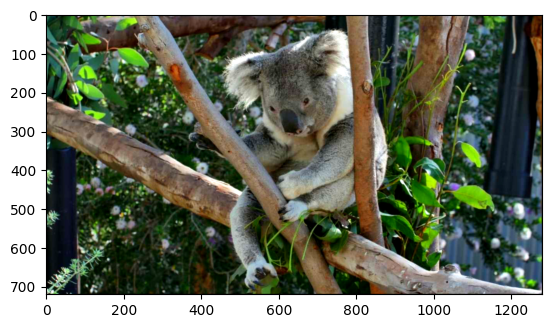

In [7]:
from image_enhancer import enhance_image
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

image = enhance_image("l_image.jpg")
plt.imshow(image)

In [8]:
model = YOLO("ml_models/yolo_animals.pt")

In [11]:
model.predict("image.png")


image 1/1 c:\Users\aliap\OneDrive\ \WildFrame\image.png: 640x448 1 Rabbit, 436.8ms
Speed: 7.6ms preprocess, 436.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 448)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Lion', 1: 'Rabbit'}
 obb: None
 orig_img: array([[[107, 107, 119],
         [108, 108, 120],
         [109, 109, 123],
         ...,
         [117, 147, 152],
         [115, 144, 149],
         [110, 139, 144]],
 
        [[100, 100, 112],
         [102, 102, 114],
         [104, 104, 118],
         ...,
         [114, 144, 149],
         [113, 142, 147],
         [110, 139, 144]],
 
        [[ 95,  95, 109],
         [ 98,  98, 112],
         [102, 101, 117],
         ...,
         [110, 139, 143],
         [112, 139, 143],
         [111, 138, 142]],
 
        ...,
 
        [[102, 158, 147],
         [102, 158, 147],
         [108, 164, 153],
         ...,
         [194, 210, 216],
         [192, 208, 214],
         [199, 215, 221]],
 
        [[ 99, 161, 149],
         [ 95, 155, 144],
         [ 97, 157, 146],
         ...,
       


image 1/1 c:\Users\aliap\OneDrive\ \WildFrame\l_image.jpg: 384x640 2 Lions, 306.0ms
Speed: 6.4ms preprocess, 306.0ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)
Detected: Lion (confidence: 31.81%)
- Lion: 31.81%
- Lion: 29.46%


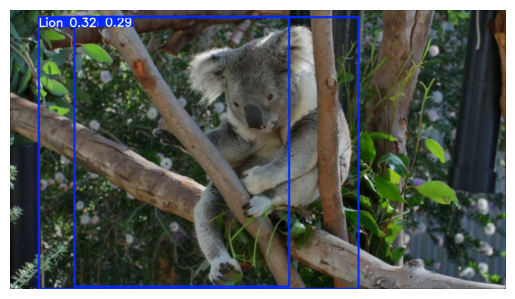

In [14]:
# Run prediction
results = model.predict("l_image.jpg")

# Get the first result (if multiple images, iterate through results)
result = results[0]

# Check if any objects were detected
if len(result.boxes) > 0:
    # Get the first detected object
    box = result.boxes[0]
    
    # Get class ID and name
    class_id = int(box.cls[0])
    class_name = result.names[class_id]  # Animal name
    
    # Get confidence score
    confidence = float(box.conf[0])
    
    print(f"Detected: {class_name} (confidence: {confidence:.2%})")
    
    # Get all detections
    for box in result.boxes:
        class_id = int(box.cls[0])
        animal = result.names[class_id]
        conf = float(box.conf[0])
        print(f"- {animal}: {conf:.2%}")
else:
    print("No animals detected")

# Visualize with bounding boxes
annotated_image = result.plot()  # Returns image with boxes drawn
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()